In [112]:
import os
import glob
import re
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 13})  # Adjust the font size as desired

def extract_test_proportion(csv_file):
    match = re.search(r"(?:^|[\\/])test-proportion-(\d+)(?:[\\/]|$)", csv_file)
    if match is None:
        return None
    return int(match.group(1))

def load_reports_by_proportion(data_item, test_type, default_proportion=None, require_proportion=False):
    csv_files_path = glob.glob(data_item + os.sep + "**" + os.sep + "*" + test_type + ".csv", recursive=True)
    reports = {}
    for csv_file in csv_files_path:
        proportion = extract_test_proportion(csv_file)
        if proportion is None:
            if require_proportion:
                continue
            proportion = default_proportion
        if proportion is None:
            continue
        reports[proportion] = pd.read_csv(csv_file, header="infer", index_col=0)
    return reports

# Frame-level Inference

Inferences are made using the deep learning model at every frame of the input video

In [113]:
def plot_confusion_matrix(labels, predictions, title, label_names, filename):
    cm = confusion_matrix(labels, predictions)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt=".1f", cmap="Blues", xticklabels=label_names, yticklabels=label_names, annot_kws={"size": 22}, cbar=False)
    plt.title(title, fontsize=24, weight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=18, weight='bold')
    plt.yticks(rotation=0, fontsize=18, weight='bold')
    plt.tight_layout()  # Adjust layout to fit labels
    os.makedirs(os.path.join(os.getcwd(), "output"), exist_ok=True)
    plt.savefig(os.path.join(os.getcwd(), "output", filename))
    plt.close()

In [114]:
L10_path = "/data1/GraphModellingExperiments/L10/IEEEPaper/C3D/w30-o29/confusion-matrix-unseenTest.pkl"
L10_label_names = ["Labelling-I", "Labelling-II", "Position MB", "Scan MB\nLabels", "Insert PCIe\nFillers", "Insert CSSD\nCard", "Push-Secure\nMotherboard", "Route\nCabling", "Get Next\nChassis", "Miscellaneous"]
AssemblyDemo_path = "/data1/GraphModellingExperiments/AssemblyDemo/IEEEPaper/Detectron2/w30-o29/confusion-matrix-unseenTest.pkl"
AssemblyDemo_label_names = ["Position\nMotherboard", "Attach\nBracket", "Secure\nMotherboard", "Insert\nCard", "Attach\nDevice", "Remove\nBattery", "Miscellaneous"]

# Load the pickle files
L10_data = pickle.load(open(L10_path, "rb"))
AssemblyDemo_data = pickle.load(open(AssemblyDemo_path, "rb"))

plot_confusion_matrix(L10_data["labels"], L10_data["predictions"], title = "Dataset-I", label_names=L10_label_names, filename="cm-d1-c3d.png")
plot_confusion_matrix(AssemblyDemo_data["labels"], AssemblyDemo_data["predictions"], title = "Dataset-II", label_names=AssemblyDemo_label_names, filename="cm-d2-d2.png")

# Impact of testing proportions

- The proportion of data available was varied for testing for every training cycle
- Proportions are [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
    - The proportions can change 

In [4]:
# Results directory
assembly_type = "AssemblyDemo"
results_dir = f"/data1/GraphModellingExperiments/{assembly_type}/TrainEval"
classes_type = "WithHands"
results_dir = os.path.join(results_dir, classes_type)
# Temporal information 
temporal_classes = ["1", "2", "6"]
temporal_classes.insert(0, "sc")

# Type of test
test_type = "unseenTest"


In [5]:
# Final directory
data_dir = os.path.join(results_dir, "-".join(temporal_classes))
# Get all files inside
data_items = glob.glob(data_dir + os.sep + "*")

# Load all the csv files
df_dict = {}
for data_item in data_items:
    
    # Find all the csv files within
    csv_files_path = glob.glob(data_item + os.sep + "**" + os.sep + "test-proportion-*" + os.sep + "*" + test_type + ".csv", recursive=True)
    df_dict[data_item.split(os.sep)[-1]] = {}
    for csv_file in csv_files_path:
        # Get the proportion
        proportion = extract_test_proportion(csv_file)
        if proportion is None:
            continue
        df_dict[data_item.split(os.sep)[-1]][proportion] = pd.read_csv(csv_file, header="infer", index_col=0)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'Macro avg. f1 vs Proportions of test data (Temporal Class sc-1-2-6 )')

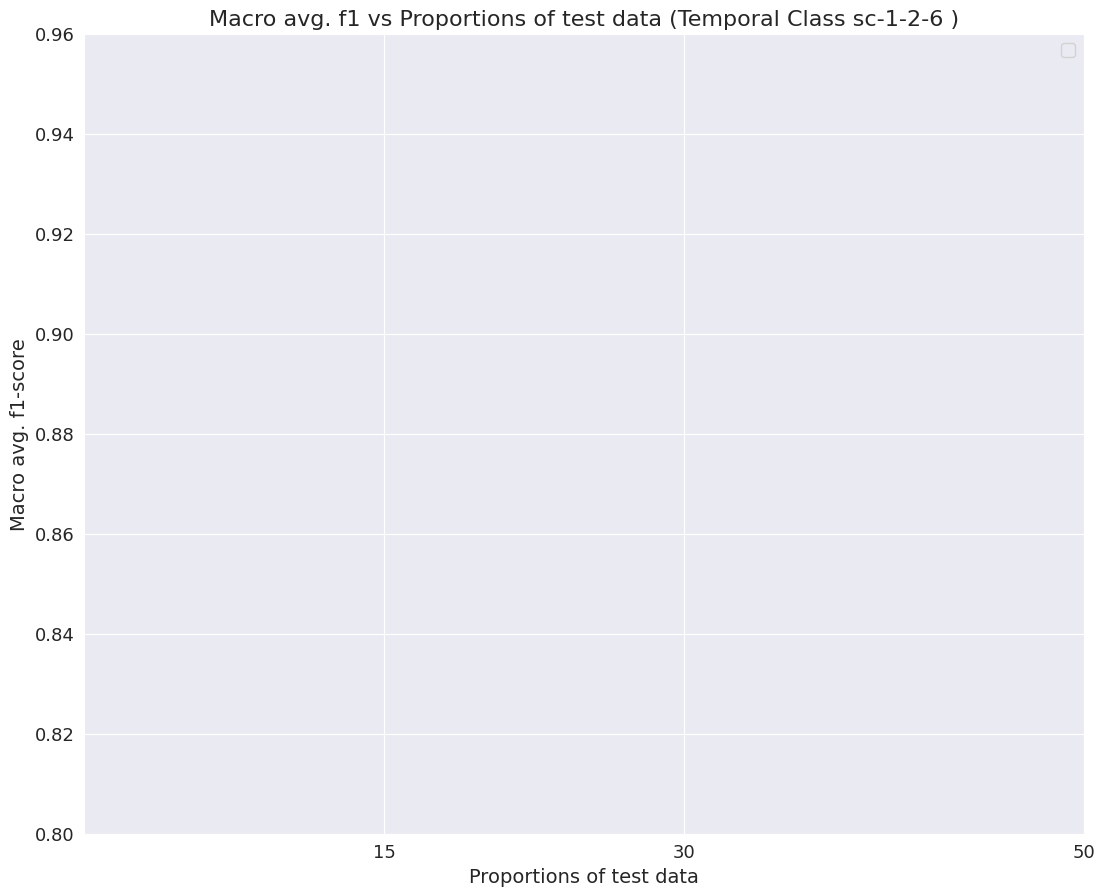

In [6]:
# Plotting the results
metric_to_consider = "macro avg"
# proportions = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
proportions = [15, 30, 50]
df_parsed_data = {}
for wo_config in df_dict.keys():
    df_parsed_data[wo_config] = []
    for proportion in proportions:
        df_parsed_data[wo_config].append(df_dict[wo_config][proportion].loc[metric_to_consider]["f1-score"])

# Plots
fig = plt.figure(figsize=(10, 8))
axs = fig.add_subplot([0, 0, 1, 1])

ordered_key_items = ["w30-o0", "w30-o10", "w30-o15", "w30-o25", "w15-o14", "w30-o29"]
for index, wo_config in enumerate(ordered_key_items):
    if wo_config not in df_parsed_data.keys():
        continue
    axs.plot(proportions, df_parsed_data[wo_config], label=wo_config, linewidth=3, color=plt.cm.tab10(index))
axs.legend()
axs.set_xticks(proportions)
axs.set_ylim([0.80, 0.96])
axs.set_xlabel("Proportions of test data", fontsize=14)
axs.set_ylabel("Macro avg. f1-score", fontsize=14)
axs.set_title(f"Macro avg. f1 vs Proportions of test data (Temporal Class { '-'.join(temporal_classes)} )", fontsize=16)

# Overlap Rate

## Impact of Overlap rate

In [120]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None

ASSEMBLY_OVERLAP_CONFIG = {
    "AssemblyDemo": {
        "classes_type": "WithHands",
        "temporal_classes": ["sc-1-2", "sc-1-2-8", "sc-8"],
        "class_id_name_mapping": {
            "sc-8": "Motherboard",
            "sc-1-2": "Hands",
            "sc-1-2-8": "Hands + Motherboard",
        },
        "class_plot_order": ["sc-8", "sc-1-2", "sc-1-2-8"],
        "plot_title": "Dataset-II",
        "output_filename": "ov_tp_d2.png",
    },
    "L10": {
        "classes_type": "WithoutHands",
        "temporal_classes": ["sc-12", "sc-11", "sc-11-12"],
        "class_id_name_mapping": {
            "sc-11": "Motherboard",
            "sc-12": "Person",
            "sc-11-12": "Person + Motherboard",
        },
        "class_plot_order": ["sc-11", "sc-12", "sc-11-12"],
        "plot_title": "Dataset-I",
        "output_filename": "ov_tp_d1.png",
    },
}

def apply_overlap_config(selected_assembly):
    global assembly_type, overlap_cfg, classes_type, fet_model_type, results_dir
    global temporal_classes, class_id_name_mapping, class_plot_order, plot_title, output_filename, test_type

    assembly_type = selected_assembly
    overlap_cfg = ASSEMBLY_OVERLAP_CONFIG[assembly_type]
    classes_type = overlap_cfg["classes_type"]
    fet_model_type = "Detectron2"
    results_dir = os.path.join(f"/data1/GraphModellingExperiments/{assembly_type}/TrainEval", classes_type, fet_model_type)
    temporal_classes = overlap_cfg["temporal_classes"]
    class_id_name_mapping = overlap_cfg["class_id_name_mapping"]
    class_plot_order = overlap_cfg["class_plot_order"]
    plot_title = overlap_cfg["plot_title"]
    output_filename = overlap_cfg["output_filename"]
    test_type = "unseenTest"

    print(f"Assembly: {assembly_type}")
    print(f"Results directory: {results_dir}")
    print(f"Temporal classes: {temporal_classes}")


default_assembly = globals().get("assembly_type", "L10")
if default_assembly not in ASSEMBLY_OVERLAP_CONFIG:
    default_assembly = "L10"

if widgets is not None:
    if "assembly_dropdown" not in globals():
        assembly_dropdown = widgets.Dropdown(
            options=list(ASSEMBLY_OVERLAP_CONFIG.keys()),
            value=default_assembly,
            description="Assembly:",
            style={"description_width": "initial"},
        )

    def on_overlap_assembly_change(change):
        if change["name"] == "value":
            apply_overlap_config(change["new"])

    assembly_dropdown.unobserve_all()
    assembly_dropdown.observe(on_overlap_assembly_change, names="value")
    display(assembly_dropdown)
    apply_overlap_config(assembly_dropdown.value)
else:
    apply_overlap_config(default_assembly)

Assembly: L10
Results directory: /data1/GraphModellingExperiments/L10/TrainEval/WithoutHands/Detectron2
Temporal classes: ['sc-12', 'sc-11', 'sc-11-12']


In [116]:
print(f"The class used for inference is {temporal_classes}")

# proportions = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
proportions = [20]

df_parsed_data = {}
for temporal_class in temporal_classes:

    data_dir = os.path.join(results_dir, temporal_class)
    # Get all files
    data_items = glob.glob(data_dir + os.sep + "*")

    # Respective temporal class
    df_parsed_data[temporal_class] = {}

    # Load all the csv files
    df_dict = {}
    for data_item in data_items:
        df_dict[data_item.split(os.sep)[-1]] = load_reports_by_proportion(
            data_item,
            test_type,
            default_proportion=proportions[0] if len(proportions) == 1 else None,
            require_proportion=False,
        )

    # Plotting the results
    metric_to_consider = "macro avg"
    for wo_config in df_dict.keys():
        df_parsed_data[temporal_class][wo_config] = []
        for proportion in proportions:
            try:
                df_parsed_data[temporal_class][wo_config].append(df_dict[wo_config][proportion].loc[metric_to_consider]["f1-score"])
            except KeyError:
                continue

The class used for inference is ['sc-12', 'sc-11', 'sc-11-12']


In [117]:
# Get the average for a class
wo_averaged = {}
for temporal_class in temporal_classes:
    wo_averaged[temporal_class] = {}
    if len(proportions) > 1:
        for wo_config in df_parsed_data[temporal_class].keys():
            wo_averaged[temporal_class][wo_config] = np.mean(df_parsed_data[temporal_class][wo_config][2:])
    else:
        for wo_config in df_parsed_data[temporal_class].keys():
            values = df_parsed_data[temporal_class][wo_config]
            wo_averaged[temporal_class][wo_config] = values[0] if values else np.nan


In [118]:
wo_averaged

{'sc-12': {'w30-o29': nan,
  'w30-o25': 0.7032731377213769,
  'w30-o10': 0.4655625955955309,
  'w30-o15': 0.5637533920488588,
  'w15-o14': 0.5726462521317953,
  'w30-o0': 0.4683113975083897},
 'sc-11': {'w30-o29': 0.6147821416545163,
  'w30-o25': 0.6437713685722246,
  'w30-o10': 0.5250998661939533,
  'w30-o15': 0.5010625036901933,
  'w15-o14': 0.6692043703130861,
  'w30-o0': 0.5022876754794946},
 'sc-11-12': {'w30-o29': 0.7006510213907706,
  'w30-o25': 0.5982832764871641,
  'w30-o10': 0.4540092400665045,
  'w30-o15': 0.6051983624127091,
  'w15-o14': 0.644935953358967,
  'w30-o0': 0.4654889417153428}}

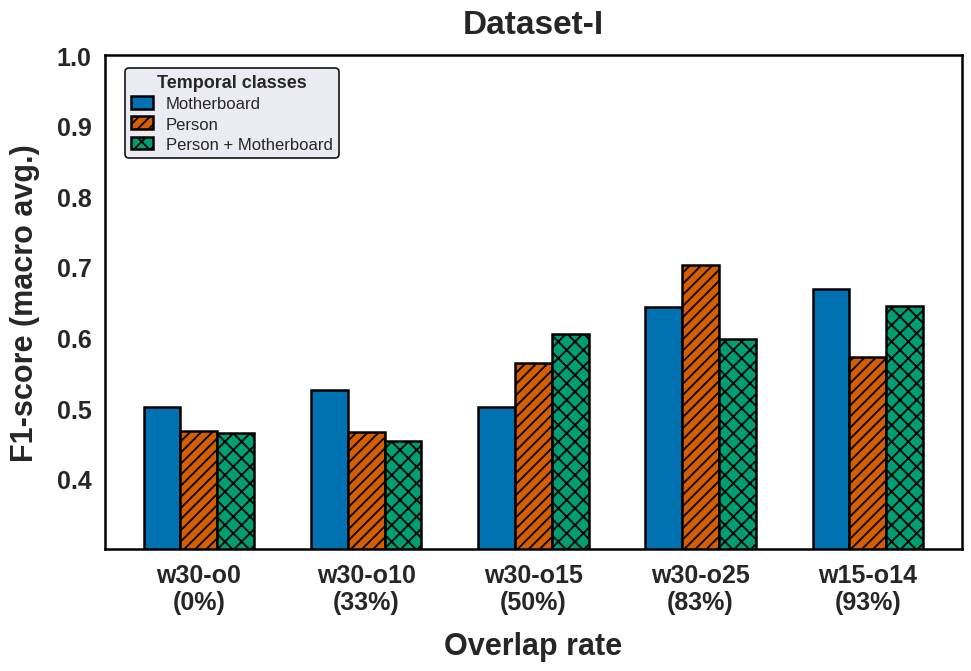

In [111]:
# Ordered keys for bar chart (sorted consistently across classes)
ordered_key_items = ["w30-o0", "w30-o10", "w30-o15", "w30-o25", "w15-o14"]

# Publication-style plotting defaults
from matplotlib import font_manager
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
preferred_font = next((font for font in ["Helvetica", "Arial", "Liberation Sans", "DejaVu Sans"] if font in available_fonts), "DejaVu Sans")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [preferred_font, "Helvetica", "Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 16,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 1.8,
    "xtick.major.width": 1.6,
    "ytick.major.width": 1.6,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "hatch.linewidth": 1.3,
})

# Bar charts for a class
fig, axs = plt.subplots(figsize=(10, 7), facecolor="white")
axs.set_facecolor("white")

# Bar chart settings
width = 0.22
bar_positions = np.arange(len(ordered_key_items))

overlap_rates = []

# Color-blind friendly colors plus hatch patterns for black-and-white printing
bar_colors = ["#0072B2", "#D55E00", "#009E73"]
bar_hatches = ["", "///", "xx"]
available_classes = [(sc_key, wo_averaged[sc_key]) for sc_key in class_plot_order if sc_key in wo_averaged]
group_offset = width * (len(available_classes) - 1) / 2

# Loop over each temporal class and plot corresponding bars
for index, (sc_key, sc_data) in enumerate(available_classes):
    for wo_config_index, wo_config in enumerate(ordered_key_items):
        if wo_config not in sc_data:
            continue

        overlap_rate = round(int(wo_config.split("-")[1][1:]) / int(wo_config.split("-")[0][1:]), 2)
        tick_label = f"{wo_config}\n({round(overlap_rate * 100)}%)"
        if tick_label not in overlap_rates:
            overlap_rates.append(tick_label)

        axs.bar(
            bar_positions[wo_config_index] + width * index - group_offset,
            sc_data[wo_config],
            width=width,
            label=class_id_name_mapping[sc_key] if wo_config_index == 0 else "",
            color=bar_colors[index % len(bar_colors)],
            edgecolor="black",
            linewidth=1.8,
            hatch=bar_hatches[index % len(bar_hatches)],
        )

# Axis information
axs.set_xlabel("Overlap rate", fontsize=22, fontweight="bold", labelpad=12)
axs.set_ylabel("F1-score (macro avg.)", fontsize=22, fontweight="bold", labelpad=12)
axs.set_title(plot_title, fontsize=24, fontweight="bold", pad=16)

# Ticks and gridlines for easier value estimation
axs.set_xticks(bar_positions)
axs.set_xticklabels(overlap_rates, fontsize=18, fontweight="bold")
axs.set_ylim(0.30, 1.00)
axs.set_yticks(np.arange(0.40, 1.01, 0.10))
axs.tick_params(axis="y", labelsize=18)
for tick in axs.get_yticklabels():
    tick.set_fontweight("bold")
axs.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.45)
axs.set_axisbelow(True)

# Compact legend inside the plot area with hatch styles visible
legend = axs.legend(
    title="Temporal classes",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    fontsize=12,
    title_fontsize=13,
    frameon=True,
    edgecolor="black",
    framealpha=0.92,
    labelspacing=0.3,
    handlelength=1.3,
    handleheight=0.8,
    borderpad=0.35,
    borderaxespad=0.2,
)
legend.get_title().set_fontweight("bold")
legend.get_frame().set_linewidth(1.2)

# Clear, bold axes box
for spine in axs.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.8)

plt.xticks(rotation=0)
plt.tight_layout()
output_dir = os.path.join(os.getcwd(), "output")
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, output_filename), dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

## Impact of Overlap rate - Selected Classes

In [122]:
# Selected temporal classes to include in this overlap-rate plot
selected_temporal_class_names = ["Motherboard", "Person"]

reverse_class_name_mapping = {name: class_id for class_id, name in class_id_name_mapping.items()}
selected_temporal_classes = [
    reverse_class_name_mapping[name]
    for name in selected_temporal_class_names
    if name in reverse_class_name_mapping
]
missing_temporal_class_names = [
    name for name in selected_temporal_class_names
    if name not in reverse_class_name_mapping
]

if missing_temporal_class_names:
    print(f"Skipping unavailable classes for {assembly_type}: {missing_temporal_class_names}")

print(f"Selected temporal classes: {selected_temporal_classes}")

proportions = [20]
metric_to_consider = "macro avg"

selected_df_parsed_data = {}
for temporal_class in selected_temporal_classes:
    data_dir = os.path.join(results_dir, temporal_class)
    data_items = glob.glob(data_dir + os.sep + "*")

    selected_df_parsed_data[temporal_class] = {}
    df_dict = {}
    for data_item in data_items:
        df_dict[data_item.split(os.sep)[-1]] = load_reports_by_proportion(
            data_item,
            test_type,
            default_proportion=proportions[0] if len(proportions) == 1 else None,
            require_proportion=False,
        )

    for wo_config in df_dict.keys():
        selected_df_parsed_data[temporal_class][wo_config] = []
        for proportion in proportions:
            try:
                selected_df_parsed_data[temporal_class][wo_config].append(
                    df_dict[wo_config][proportion].loc[metric_to_consider]["f1-score"]
                )
            except KeyError:
                continue


Selected temporal classes: ['sc-11', 'sc-12']


In [123]:
# Average selected-class scores across requested proportions
selected_wo_averaged = {}
for temporal_class in selected_temporal_classes:
    selected_wo_averaged[temporal_class] = {}
    if len(proportions) > 1:
        for wo_config in selected_df_parsed_data[temporal_class].keys():
            selected_wo_averaged[temporal_class][wo_config] = np.mean(
                selected_df_parsed_data[temporal_class][wo_config][2:]
            )
    else:
        for wo_config in selected_df_parsed_data[temporal_class].keys():
            values = selected_df_parsed_data[temporal_class][wo_config]
            selected_wo_averaged[temporal_class][wo_config] = values[0] if values else np.nan

selected_wo_averaged


{'sc-11': {'w30-o29': 0.6147821416545163,
  'w30-o25': 0.6437713685722246,
  'w30-o10': 0.5250998661939533,
  'w30-o15': 0.5010625036901933,
  'w15-o14': 0.6692043703130861,
  'w30-o0': 0.5022876754794946},
 'sc-12': {'w30-o29': nan,
  'w30-o25': 0.7032731377213769,
  'w30-o10': 0.4655625955955309,
  'w30-o15': 0.5637533920488588,
  'w15-o14': 0.5726462521317953,
  'w30-o0': 0.4683113975083897}}

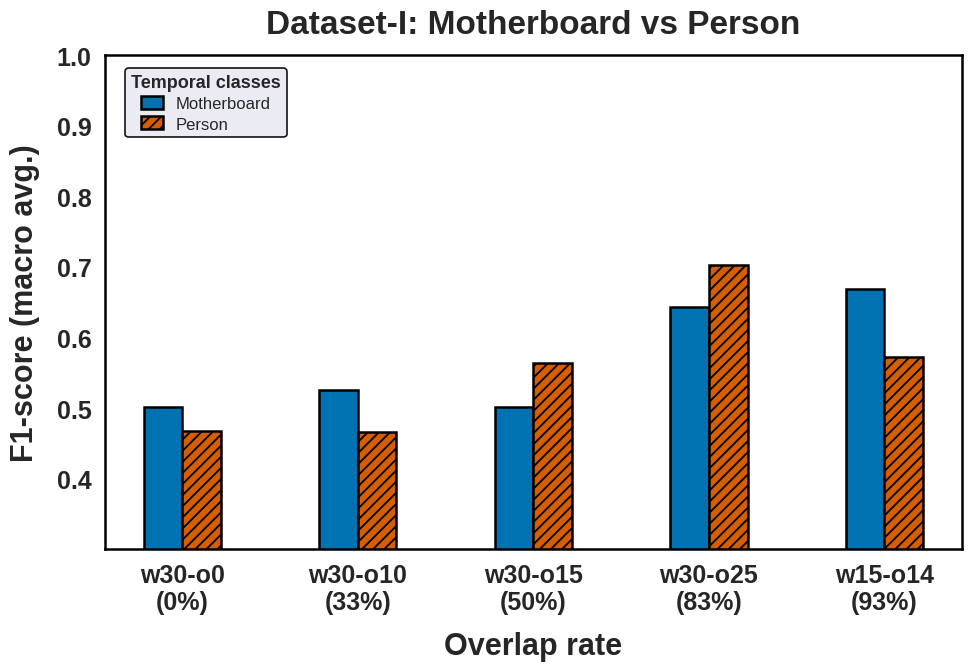

In [126]:
# Ordered keys for bar chart (sorted consistently across classes)
ordered_key_items = ["w30-o0", "w30-o10", "w30-o15", "w30-o25", "w15-o14"]

# Publication-style plotting defaults
from matplotlib import font_manager
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
preferred_font = next((font for font in ["Helvetica", "Arial", "Liberation Sans", "DejaVu Sans"] if font in available_fonts), "DejaVu Sans")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [preferred_font, "Helvetica", "Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 16,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 1.8,
    "xtick.major.width": 1.6,
    "ytick.major.width": 1.6,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "hatch.linewidth": 1.3,
})

fig, axs = plt.subplots(figsize=(10, 7), facecolor="white")
axs.set_facecolor("white")

width = 0.22
bar_positions = np.arange(len(ordered_key_items))
overlap_rates = []

bar_colors = ["#0072B2", "#D55E00", "#009E73"]
bar_hatches = ["", "///", "xx"]
available_classes = [
    (sc_key, selected_wo_averaged[sc_key])
    for sc_key in class_plot_order
    if sc_key in selected_wo_averaged
]
group_offset = width * (len(available_classes) - 1) / 2

for index, (sc_key, sc_data) in enumerate(available_classes):
    for wo_config_index, wo_config in enumerate(ordered_key_items):
        if wo_config not in sc_data:
            continue

        overlap_rate = round(int(wo_config.split("-")[1][1:]) / int(wo_config.split("-")[0][1:]), 2)
        tick_label = f"{wo_config}\n({round(overlap_rate * 100)}%)"
        if tick_label not in overlap_rates:
            overlap_rates.append(tick_label)

        axs.bar(
            bar_positions[wo_config_index] + width * index - group_offset,
            sc_data[wo_config],
            width=width,
            label=class_id_name_mapping[sc_key] if wo_config_index == 0 else "",
            color=bar_colors[index % len(bar_colors)],
            edgecolor="black",
            linewidth=1.8,
            hatch=bar_hatches[index % len(bar_hatches)],
        )

axs.set_xlabel("Overlap rate", fontsize=22, fontweight="bold", labelpad=12)
axs.set_ylabel("F1-score (macro avg.)", fontsize=22, fontweight="bold", labelpad=12)
axs.set_title(f"{plot_title}: Motherboard vs Person", fontsize=24, fontweight="bold", pad=16)

axs.set_xticks(bar_positions)
axs.set_xticklabels(overlap_rates, fontsize=18, fontweight="bold")
axs.set_ylim(0.30, 1.00)
axs.set_yticks(np.arange(0.40, 1.01, 0.10))
axs.tick_params(axis="y", labelsize=18)
for tick in axs.get_yticklabels():
    tick.set_fontweight("bold")
axs.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.45)
axs.set_axisbelow(True)

legend = axs.legend(
    title="Temporal classes",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    fontsize=12,
    title_fontsize=13,
    frameon=True,
    edgecolor="black",
    framealpha=0.92,
    labelspacing=0.3,
    handlelength=1.3,
    handleheight=0.8,
    borderpad=0.35,
    borderaxespad=0.2,
)
legend.get_title().set_fontweight("bold")
legend.get_frame().set_linewidth(1.2)

for spine in axs.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.8)

plt.xticks(rotation=0)
plt.tight_layout()
output_dir = os.path.join(os.getcwd(), "output")
os.makedirs(output_dir, exist_ok=True)
selected_output_filename = output_filename.replace(".png", "_selected.png")
fig.savefig(os.path.join(output_dir, selected_output_filename), dpi=600, bbox_inches="tight", facecolor="white")
plt.show()


# Misc - Below is not part of the paper

## Compare between the two classes

In [ ]:
# Results directory
results_dir = f"/data1/GraphModellingExperiments/{assembly_type}/TrainEval"
classes_type = "WithHands"
results_dir = os.path.join(results_dir, classes_type)
# Temporal information 
temporal_classes_compared = ["1-2", "1-2-6"]
temporal_classes_compared = ["sc-" + x for x in temporal_classes_compared]

# Type of test
test_type = "unseenTest"

In [ ]:
# Final directory
data_dirs = [os.path.join(results_dir, x) for x in temporal_classes_compared]

df_dict_class_combined = {}
for data_dir in data_dirs:
    # Get all files inside
    data_items = glob.glob(data_dir + os.sep + "*")
    
    # Load all the csv files
    df_dict = {}
    for data_item in data_items:
        
        # Find all the csv files within
        csv_files_path = glob.glob(data_item + os.sep + "**" + os.sep + "test-proportion-*" + os.sep + "*" + test_type + ".csv", recursive=True)
        df_dict[data_item.split(os.sep)[-1]] = {}
        for csv_file in csv_files_path:
            # Get the proportion
            proportion = extract_test_proportion(csv_file)
            if proportion is None:
                continue
            df_dict[data_item.split(os.sep)[-1]][proportion] = pd.read_csv(csv_file, header="infer", index_col=0)
            
    # Add by classes
    df_dict_class_combined[data_dir.split(os.sep)[-1]] = df_dict

In [ ]:
# Plotting the results
metric_to_consider = "macro avg"
# proportions = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
proportions = [15, 30, 50]

df_parsed_class_combined = {}
for class_type in df_dict_class_combined.keys():
    df_dict = df_dict_class_combined[class_type]
    df_parsed_data = {}
    for wo_config in df_dict.keys():
        df_parsed_data[wo_config] = []
        for proportion in proportions:
            df_parsed_data[wo_config].append(df_dict[wo_config][proportion].loc[metric_to_consider]["f1-score"])
            
    df_parsed_class_combined[class_type] = df_parsed_data

In [ ]:
# Get the average of the scores 
averaged_values = {}
for class_type in df_parsed_class_combined.keys():
    averaged_values[class_type] = {}
    for wo_config in df_parsed_class_combined[class_type].keys():
        averaged_values[class_type][wo_config] = np.mean(df_parsed_class_combined[class_type][wo_config][2:])


In [ ]:
# Plotting
# Plots
fig = plt.figure(figsize=(10, 8))
axs = fig.add_subplot([0, 0, 1, 1])

# Set the bar parameters
bar_width = 0.2

# Get the similar items across the two categories
for index, class_type in enumerate(averaged_values.keys()):
    if index == 0:
        items = list(averaged_values[class_type].items())
    else:
        if len(items) > len(list(averaged_values[class_type].items())):
            items = list(averaged_values[class_type].items())

# ordered_key_items = ["w30-o0", "w30-o10", "w30-o15", "w30-o25", "w15-o14", "w30-o29"]
ordered_key_items = ["w30-o15", "w30-o25", "w15-o14", "w30-o29"]
categories = []
classes_type = list(averaged_values.keys())
for index, wo_config in enumerate(ordered_key_items):
    
    availability = all([wo_config in averaged_values[x] for x in averaged_values.keys()])
    if not availability:
        continue
    
    # Compute the proportion
    overlap_rate = round(int(wo_config.split("-")[1][1:])/int(wo_config.split("-")[0][1:]), 2)
    categories.append(wo_config + f"({overlap_rate})")
    
    # Creating bars - For all the class types considered
    for i, class_type in enumerate(classes_type):
        values = averaged_values[class_type][wo_config] 
        axs.bar(index + i * bar_width, values, width=bar_width, color=plt.cm.tab10(i), edgecolor='black', label=class_type, linewidth=3,)
    
# Axis information
axs.set_xlabel("Overlap rate", fontsize=14)
axs.set_ylabel("F1-Score (Macro-Avg)", fontsize=14)
axs.set_title(f"Macro-Avg F1-Score vs Overlap Rate across classes ({'|'.join(classes_type)})", fontsize=16)
plt.xticks([r + bar_width/2 for r in range(len(categories))], categories)
axs.legend(classes_type)


## Impact of testing proportions for each temporal class

In [ ]:
# Results directory
results_dir = "/data1/GraphModellingExperiments/L10/TrainEval"
classes_type = "WithoutHands"
results_dir = os.path.join(results_dir, classes_type)
# Temporal information 
temporal_classes = ["11", "12", "11-12"]
temporal_classes = ["sc-" + x for x in temporal_classes]

# Type of test
test_type = "unseenTest"

In [ ]:
# Final directory
data_dirs = [os.path.join(results_dir, x) for x in temporal_classes]

df_dict_class_combined = {}
for data_dir in data_dirs:
    # Get all files inside
    data_items = glob.glob(data_dir + os.sep + "*")
    
    # Load all the csv files
    df_dict = {}
    for data_item in data_items:
        
        # Find all the csv files within
        csv_files_path = glob.glob(data_item + os.sep + "**" + os.sep + "test-proportion-*" + os.sep + "*" + test_type + ".csv", recursive=True)
        df_dict[data_item.split(os.sep)[-1]] = {}
        for csv_file in csv_files_path:
            # Get the proportion
            proportion = extract_test_proportion(csv_file)
            if proportion is None:
                continue
            df_dict[data_item.split(os.sep)[-1]][proportion] = pd.read_csv(csv_file, header="infer", index_col=0)
            
    # Add by classes
    df_dict_class_combined[data_dir.split(os.sep)[-1]] = df_dict

In [ ]:
selected_overlap = "w30-o25"
proportions = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
selected_values = {}
for class_instance in df_dict_class_combined.keys():
    selected_values[class_instance] = []
    for proportion in proportions:
        selected_values[class_instance].append(df_dict_class_combined[class_instance][selected_overlap][proportion].loc["macro avg"]["f1-score"])
    

In [ ]:
# Getting the indices
indices = np.arange(len(selected_values['sc-11']))

# Plotting the grouped bar chart
plt.figure(figsize=(10, 6))

# Plot each key as a group
for i, (key, values) in enumerate(selected_values.items()):
    plt.bar(indices + 0.2*i, values, width=0.2, label=key)

plt.xlabel('Proportions')
plt.ylabel('Macro Avg F1-Score')
plt.title('Variation across different test proportion')
plt.xticks(indices + 0.2*(len(selected_values)-1)/2, proportions)
plt.legend()
plt.show()

## Comparison between WithHands and WithoutHands

In [61]:
assembly_type = "L10"
results_dir = f"/data1/GraphModellingExperiments/{assembly_type}/TrainEval/WithoutHands/Detectron2"

# Update tc names
if assembly_type == "AssemblyDemo":
    class_id_to_names = {
        "sc-1-2-8": "Hands + Motherboard",
        "sc-1-2": "Hands",
        "sc-8": "Motherboard"
    }
    class_id_order = ["sc-8", "sc-1-2", "sc-1-2-8"]
    # List all files inside
    all_files = glob.glob(os.path.join(results_dir, "**/*unseenTest.csv"), recursive=True)
elif assembly_type == "L10":
    class_id_to_names = {
        "sc-11-12": "Person + Motherboard",
        "sc-11": "Motherboard",
        "sc-12": "Person"
    }
    class_id_order = ["sc-11", "sc-12", "sc-11-12"]
    # List all files inside - Choose only one test proportion - 20%
    all_files = glob.glob(os.path.join(results_dir, "**/test-proportion-20/*unseenTest.csv"), recursive=True)

In [62]:
# Go through files and group together
results = {}
for file in all_files:
    # Get the information
    if assembly_type == "AssemblyDemo":
        temporal_class = file.split(os.sep)[-3]
        overlap_rate = file.split(os.sep)[-2]
    elif assembly_type == "L10":
        temporal_class = file.split(os.sep)[-4]
        overlap_rate = file.split(os.sep)[-3]
    
    if overlap_rate not in results.keys():
        results[overlap_rate] = {}
        
    if temporal_class not in results[overlap_rate].keys():
        results[overlap_rate][temporal_class] = []
        
    results[overlap_rate][temporal_class].append(pd.read_csv(file, header="infer", index_col=0).loc["macro avg"]["f1-score"])
    
# Average them
data = {outer_key: {inner_key: sum(inner_list) / len(inner_list) for inner_key, inner_list in outer_value.items()} for outer_key, outer_value in results.items()}
    

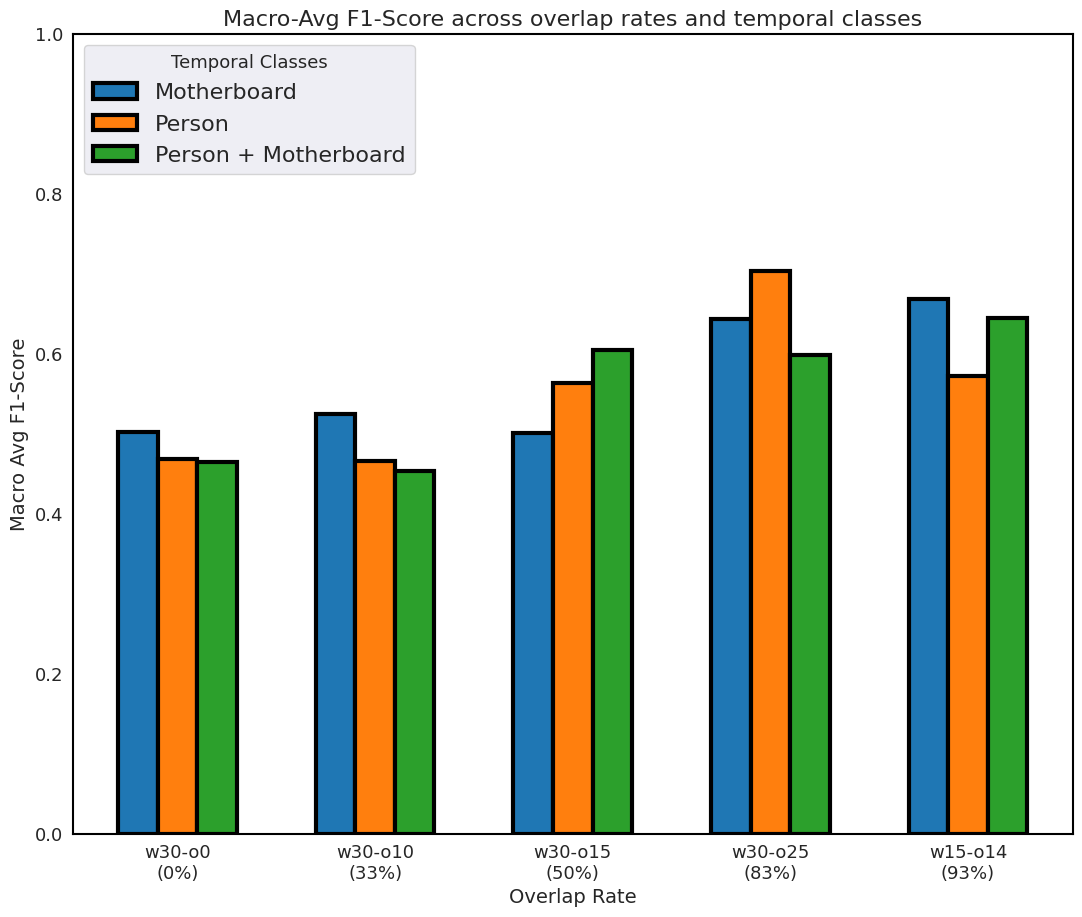

In [63]:
outer_keys = list(data.keys())
overlap_rates = {wo_config: round(int(wo_config.split("-")[1][1:]) / int(wo_config.split("-")[0][1:]), 2) for wo_config in outer_keys}
outer_keys = sorted(outer_keys, key=lambda x: overlap_rates[x])

# Remove overlap rates if required
outer_keys.remove("w30-o29")

categories = []
for wo_config in outer_keys:
    overlap_rate = round(int(wo_config.split("-")[1][1:])/int(wo_config.split("-")[0][1:]), 2)
    categories.append(wo_config + f"\n({round(overlap_rate * 100)}%)")

inner_keys = class_id_order
num_inner_keys = len(inner_keys)
bar_width = 0.2
index = range(len(outer_keys))

fig = plt.figure(figsize=(10, 8), facecolor="white")
axs = fig.add_subplot([0, 0, 1, 1])
axs.set_facecolor("white")

for i in range(num_inner_keys):
    values = [data[key][inner_keys[i]] for key in outer_keys]
    axs.bar([x + i * bar_width for x in index], values, bar_width, label=class_id_to_names[inner_keys[i]], color=plt.cm.tab10(i), edgecolor='black', linewidth=3,)

axs.set_xlabel('Overlap Rate', fontsize=14)
axs.set_ylabel('Macro Avg F1-Score', fontsize=14)
axs.set_title('Macro-Avg F1-Score across overlap rates and temporal classes', fontsize=16)
axs.set_ylim([0, 1.0])
plt.xticks([x + (num_inner_keys - 1) * bar_width / 2 for x in index], categories)
axs.legend()
axs.legend(title="Temporal Classes", loc='upper left', fontsize=16)

# Add a bounding box around the plot
for spine in axs.spines.values():
    spine.set_edgecolor('black')  # Set the color of the bounding box
    spine.set_linewidth(1.5)  # Set the width of the bounding box

plt.show()